## Part 1: Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings('ignore')

pytrends = TrendReq(hl='en-US', tz=360, requests_args={'verify': False})
keywords = ["ransomware", "cybersecurity", "data breach", "phishing", "hacking"]

# Pull web search trends
pytrends.build_payload(keywords, timeframe='2017-01-01 2024-12-31', geo='US', gprop='')
df_web = pytrends.interest_over_time().drop(columns=['isPartial'])
df_web['public_interest_index'] = df_web[keywords].mean(axis=1)

# Pull news trends
pytrends.build_payload(keywords, timeframe='2017-01-01 2024-12-31', geo='US', gprop='news')
df_news = pytrends.interest_over_time().drop(columns=['isPartial'])
df_news['media_coverage_index'] = df_news[keywords].mean(axis=1)

# Final combined DataFrame
df = pd.DataFrame({
    'web_interest': df_web['public_interest_index'],
    'news_volume': df_news['media_coverage_index']
}).fillna(0)

print(df.shape)
display(df.head())

(96, 2)


,web_interest,news_volume
date,,
2017-01-01,9.8,21.0
2017-02-01,7.4,15.6
2017-03-01,7.8,16.2
2017-04-01,7.0,14.4
2017-05-01,12.6,42.2


## Part 2: Time-Series Visualization

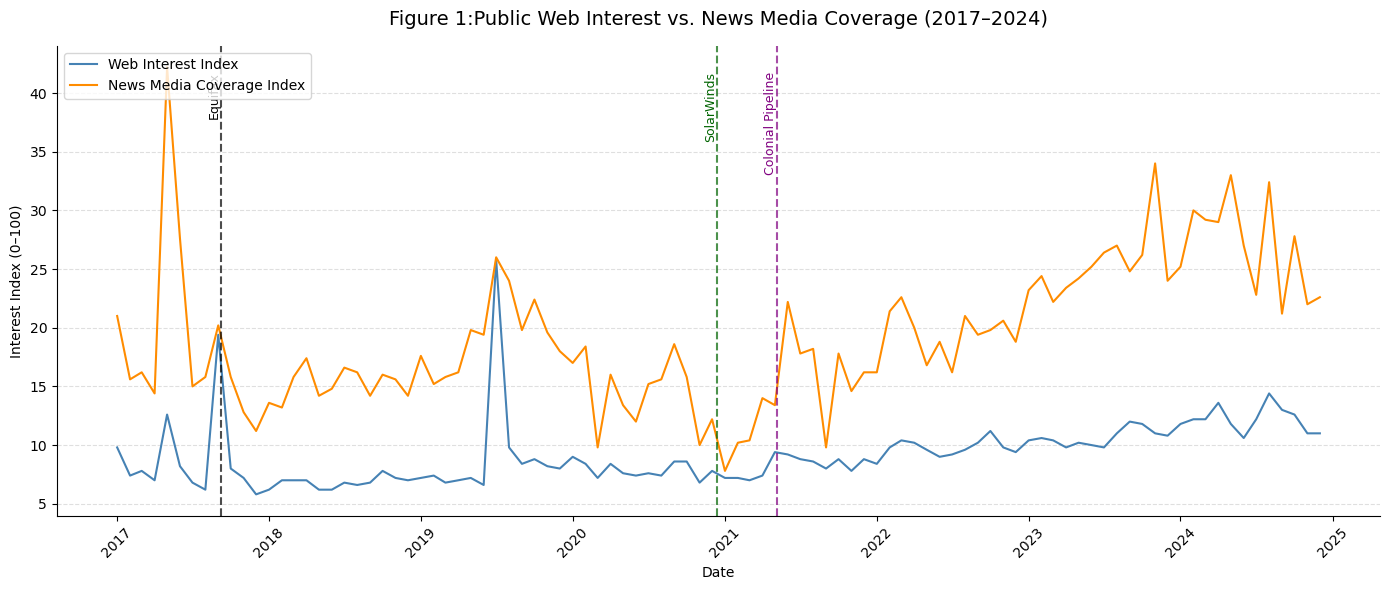

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['web_interest'], label='Web Interest Index', linewidth=1.5, color='steelblue')
ax.plot(df.index, df['news_volume'], label='News Media Coverage Index', linewidth=1.5, color='darkorange')

# Three events from the proposal to analyze
events = {
    '2017-09-07': ('Equifax', 'black'),
    '2020-12-13': ('SolarWinds', 'darkgreen'),
    '2021-05-07': ('Colonial Pipeline', 'purple')
}

for date_str, (name, color) in events.items():
    event_date = pd.to_datetime(date_str)
    ax.axvline(x=event_date, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(event_date, ax.get_ylim()[1] * 0.95, name,
            rotation=90, fontsize=9, color=color,
            va='top', ha='right')

ax.set_title('Figure 1:Public Web Interest vs. News Media Coverage (2017–2024)', fontsize=14, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Interest Index (0–100)')
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 3: K-Means Clustering

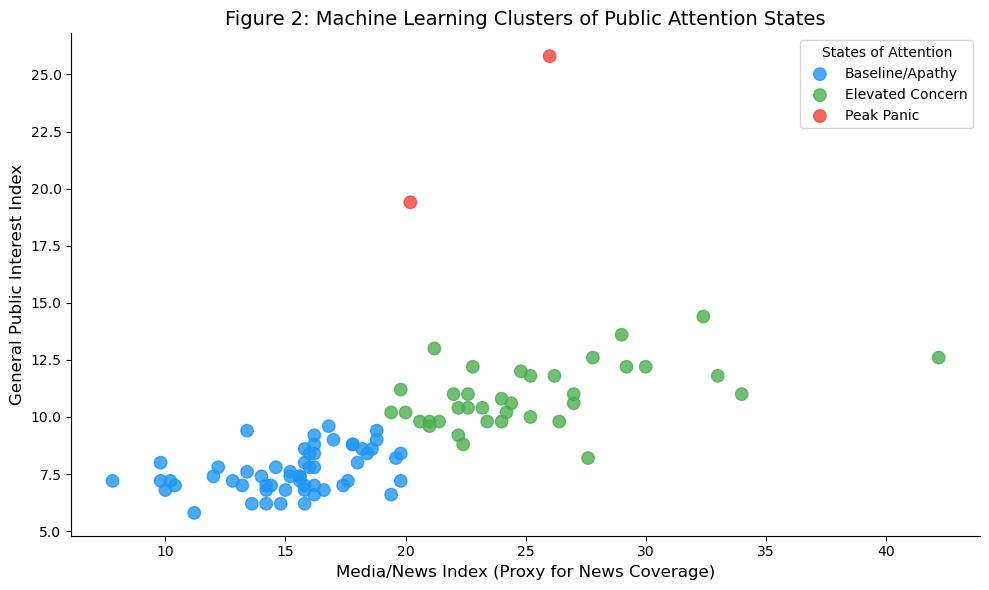

Percentage of time spent in 'Peak Panic': 2.08%


In [3]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['web_interest', 'news_volume']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Map cluster numbers to labels by ranking their mean web_interest
cluster_means = df.groupby('Cluster')['web_interest'].mean().sort_values()
label_map = {
    cluster_means.index[0]: 'Baseline/Apathy',
    cluster_means.index[1]: 'Elevated Concern',
    cluster_means.index[2]: 'Peak Panic'
}
color_map = {
    cluster_means.index[0]: '#2196F3',  # blue
    cluster_means.index[1]: '#4CAF50',  # green
    cluster_means.index[2]: '#F44336'   # red
}

df['Cluster Label'] = df['Cluster'].map(label_map)
df['Cluster Color'] = df['Cluster'].map(color_map)

plt.figure(figsize=(10, 6))
for label in ['Baseline/Apathy', 'Elevated Concern', 'Peak Panic']:
    subset = df[df['Cluster Label'] == label]
    plt.scatter(subset['news_volume'], subset['web_interest'],
                c=subset['Cluster Color'], label=label, s=80, alpha=0.8)

plt.title('Figure 2: Machine Learning Clusters of Public Attention States', fontsize=14)
plt.xlabel('Media/News Index (Proxy for News Coverage)', fontsize=12)
plt.ylabel('General Public Interest Index', fontsize=12)
plt.legend(title='States of Attention', fontsize=10)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

panic_freq = (df['Cluster Label'] == 'Peak Panic').mean() * 100
print(f"Percentage of time spent in 'Peak Panic': {round(panic_freq, 2)}%")

## Part 4: Linear Regression

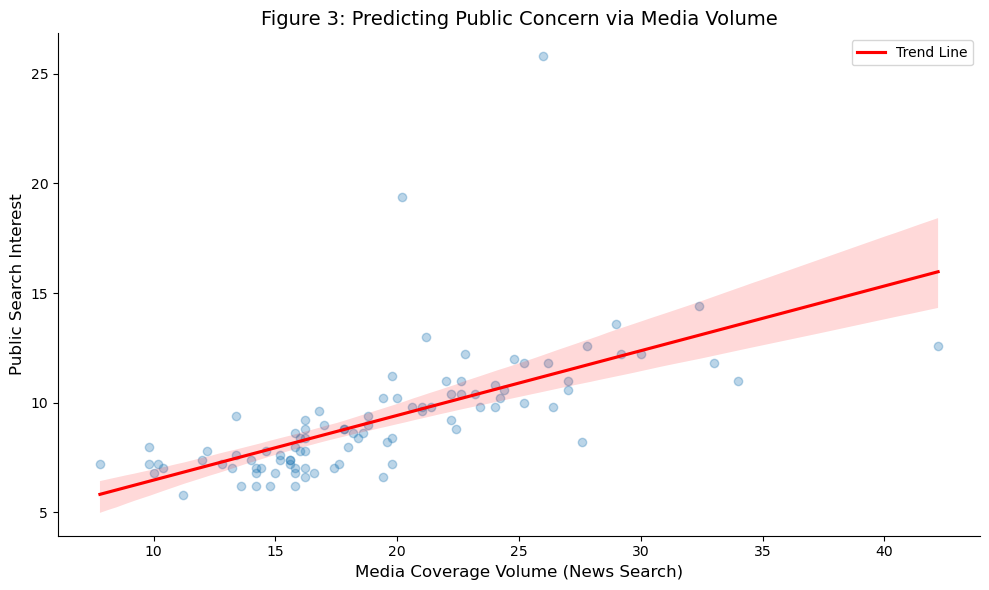

P-value for news_volume: 0.000000
R-squared: 0.4063


In [4]:
X = sm.add_constant(df['news_volume'])
Y = df['web_interest']

results = sm.OLS(Y, X).fit()

plt.figure(figsize=(10, 6))
sns.regplot(x='news_volume', y='web_interest', data=df,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red', 'label': 'Trend Line'})
plt.title('Figure 3: Predicting Public Concern via Media Volume', fontsize=14)
plt.xlabel('Media Coverage Volume (News Search)', fontsize=12)
plt.ylabel('Public Search Interest', fontsize=12)
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"P-value for news_volume: {results.pvalues['news_volume']:.6f}")
print(f"R-squared: {results.rsquared:.4f}")

## Part 5: Attention Decay Table

,Major Cyber Incident,Peak Interest Index,Interest 30 Days Later,Drop in Attention (%)
0,Equifax\n(Sep 2017),8.0,7.2,10.0%
1,SolarWinds\n(Dec 2020),7.2,7.2,0.0%
2,Colonial Pipeline\n(May 2021),9.2,8.8,4.35%


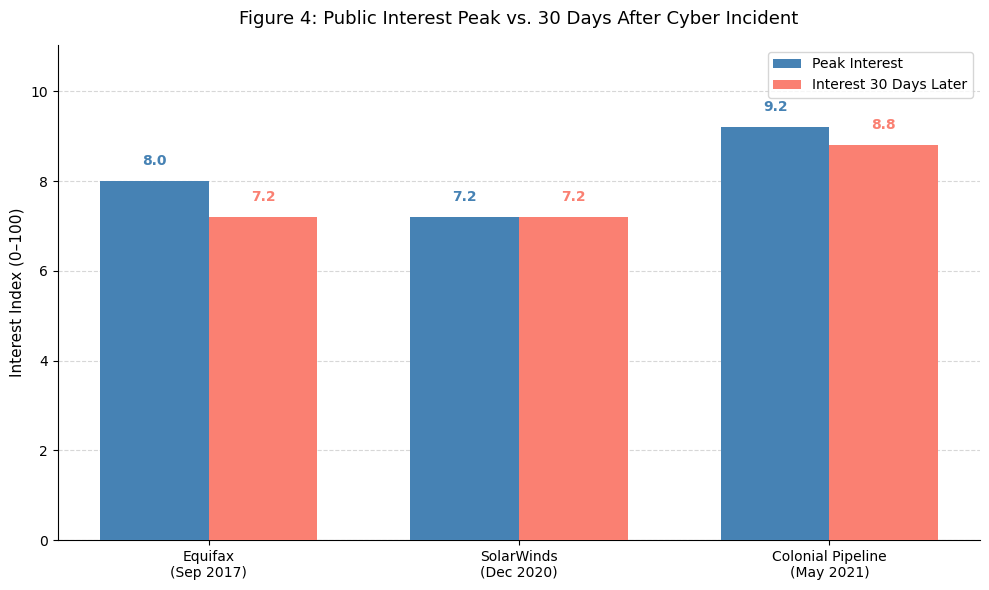

In [5]:
events = {
    '2017-09-07': 'Equifax\n(Sep 2017)',
    '2020-12-13': 'SolarWinds\n(Dec 2020)',
    '2021-05-07': 'Colonial Pipeline\n(May 2021)'
}
table_rows = []

for date_str, name in events.items():
    event_date = pd.to_datetime(date_str)

    # 60-day window for SolarWinds (slow-burn awareness), 30-day for others
    days = 60 if 'SolarWinds' in name else 30
    window = df.loc[event_date : event_date + pd.Timedelta(days=days)]

    if not window.empty:
        peak_val = window['web_interest'].max()
        peak_date = window['web_interest'].idxmax()
        target_later_date = peak_date + pd.Timedelta(days=30)
        idx_later = df.index.get_indexer([target_later_date], method='nearest')[0]
        later_val = df.iloc[idx_later]['web_interest']
        percent_drop = ((peak_val - later_val) / peak_val) * 100

        table_rows.append({
            'Major Cyber Incident': name,
            'Peak Interest Index': round(peak_val, 2),
            'Interest 30 Days Later': round(later_val, 2),
            'Drop in Attention (%)': f"{round(percent_drop, 2)}%"
        })

figure_3_table = pd.DataFrame(table_rows)
display(figure_3_table)

# Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(figure_3_table))
width = 0.35

bars1 = ax.bar(x - width/2, figure_3_table['Peak Interest Index'],
               width, label='Peak Interest', color='steelblue', zorder=3)
bars2 = ax.bar(x + width/2, figure_3_table['Interest 30 Days Later'],
               width, label='Interest 30 Days Later', color='salmon', zorder=3)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f'{height:.1f}', ha='center', va='bottom', fontsize=10,
            color='steelblue', fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f'{height:.1f}', ha='center', va='bottom', fontsize=10,
            color='salmon', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(figure_3_table['Major Cyber Incident'], fontsize=10)
ax.set_ylabel('Interest Index (0–100)', fontsize=11)
ax.set_title('Figure 4: Public Interest Peak vs. 30 Days After Cyber Incident', fontsize=13, pad=15)
ax.set_ylim(0, figure_3_table['Peak Interest Index'].max() * 1.2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()